# Multiclass Neural Network

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

PROCESSED_DIR = "../data/processed"

disciplines = ["gs", "sl", "sg"]

data = {}

for d in disciplines:

    data[d] = {
        "results": pd.read_parquet(
            f"{PROCESSED_DIR}/{d}_nn_results.parquet"
        ),

        "report": pd.read_parquet(
            f"{PROCESSED_DIR}/{d}_nn_classification_report.parquet"
        ),

        "cm": pd.read_parquet(
            f"{PROCESSED_DIR}/{d}_nn_confusion_matrix.parquet"
        ),

        "history": pd.read_parquet(
            f"{PROCESSED_DIR}/{d}_nn_history.parquet"
        )
    }

Matplotlib is building the font cache; this may take a moment.


In [3]:
gs_results = data["gs"]["results"]
gs_report = data["gs"]["report"]
gs_cm = data["gs"]["cm"]
gs_history = data["gs"]["history"]

sl_results = data["sl"]["results"]
sl_report = data["sl"]["report"]
sl_cm = data["sl"]["cm"]
sl_history = data["sl"]["history"]

sg_results = data["sg"]["results"]
sg_report = data["sg"]["report"]
sg_cm = data["sg"]["cm"]
sg_history = data["sg"]["history"]

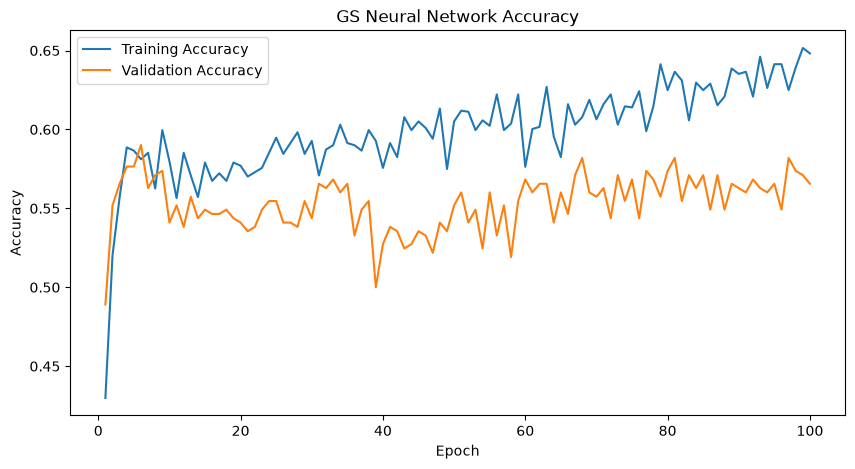

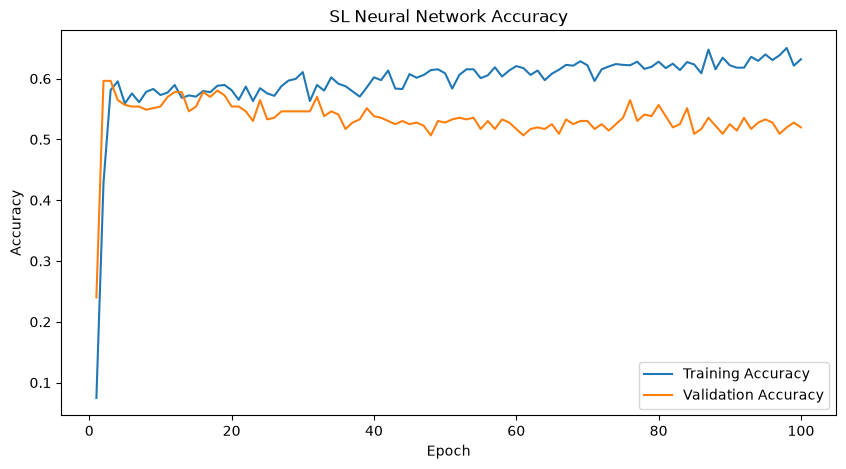

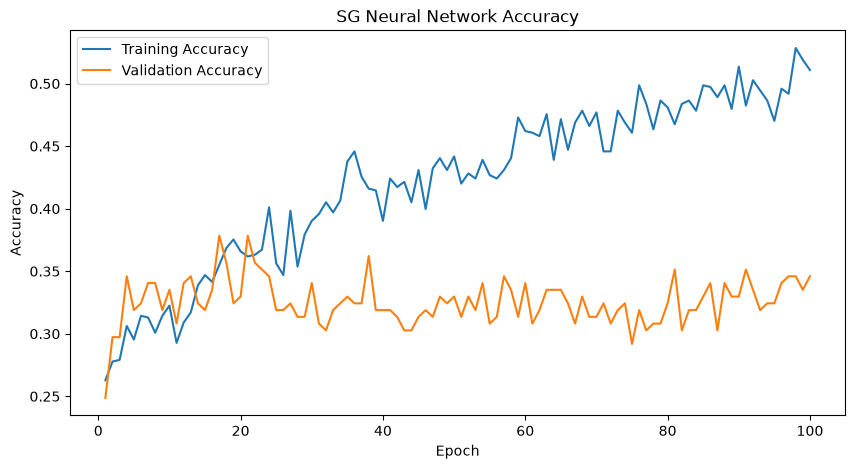

In [4]:
# Training accuracy
plt.figure(figsize=(10, 5))

plt.plot(
    gs_history["epoch"],
    gs_history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    gs_history["epoch"],
    gs_history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GS Neural Network Accuracy")
plt.legend()
plt.show()

### sl
plt.figure(figsize=(10, 5))

plt.plot(
    sl_history["epoch"],
    sl_history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    sl_history["epoch"],
    sl_history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("SL Neural Network Accuracy")
plt.legend()
plt.show()


## sg
plt.figure(figsize=(10, 5))

plt.plot(
    sg_history["epoch"],
    sg_history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    sg_history["epoch"],
    sg_history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("SG Neural Network Accuracy")
plt.legend()
plt.show()

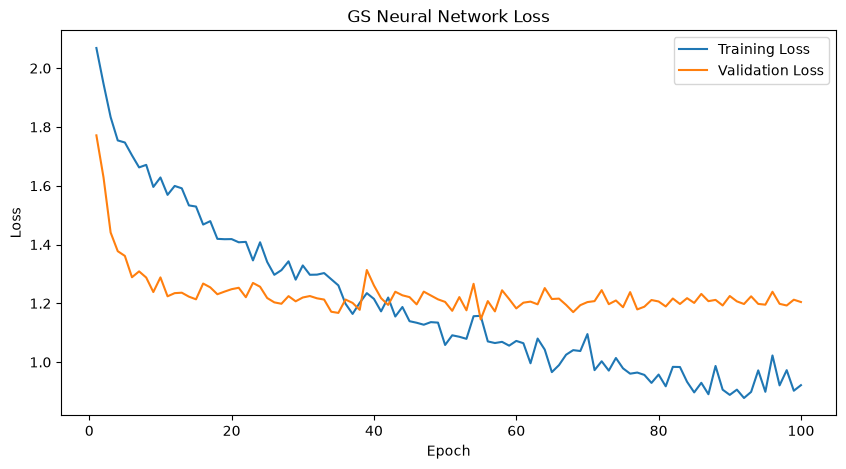

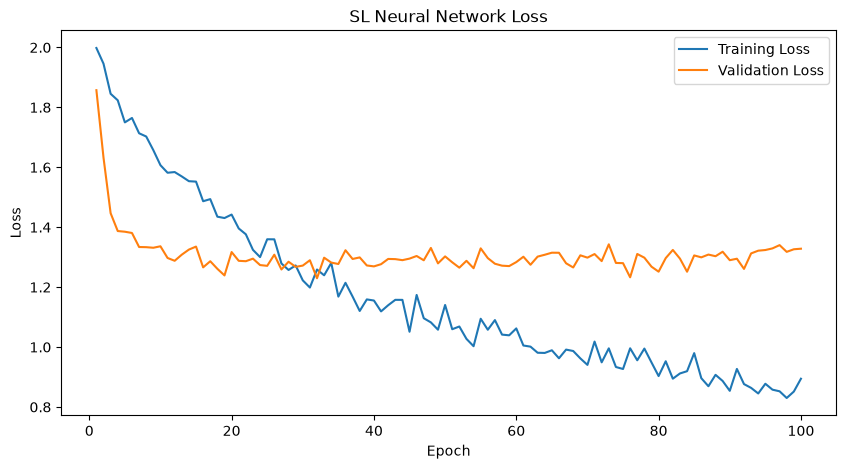

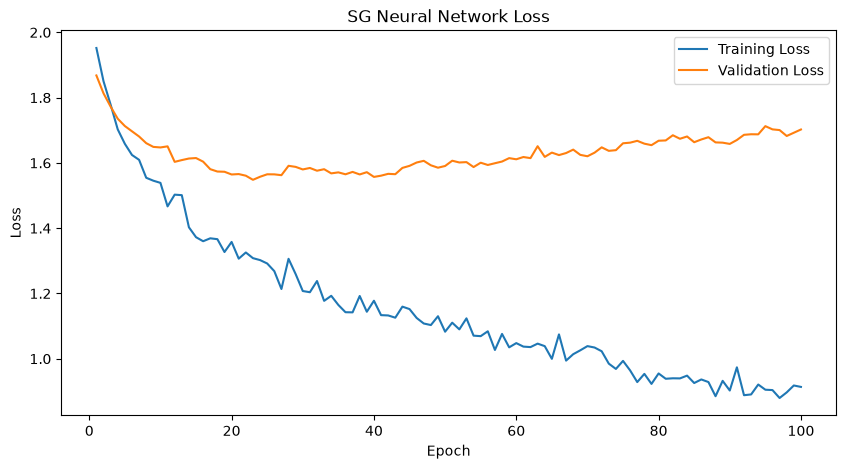

In [5]:
# Training Loss 

plt.figure(figsize=(10, 5))

plt.plot(
    gs_history["epoch"],
    gs_history["loss"],
    label="Training Loss"
)

plt.plot(
    gs_history["epoch"],
    gs_history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GS Neural Network Loss")
plt.legend()
plt.show()

## sl
plt.figure(figsize=(10, 5))

plt.plot(
    sl_history["epoch"],
    sl_history["loss"],
    label="Training Loss"
)

plt.plot(
    sl_history["epoch"],
    sl_history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SL Neural Network Loss")
plt.legend()
plt.show()


## sg
plt.figure(figsize=(10, 5))

plt.plot(
    sg_history["epoch"],
    sg_history["loss"],
    label="Training Loss"
)

plt.plot(
    sg_history["epoch"],
    sg_history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SG Neural Network Loss")
plt.legend()
plt.show()

In [6]:
# overall accuracy
for d in disciplines:

    accuracy = data[d]["report"].loc[
        "accuracy",
        "precision"
    ]

    print(f"{d.upper()} accuracy: {accuracy:.3f}")

GS accuracy: 0.569
SL accuracy: 0.555
SG accuracy: 0.368


,precision,recall,f1-score,support
0.0,0.000000,0.000000,0.000000,4.000000
1.0,0.153846,0.250000,0.190476,8.000000
2.0,0.216216,0.444444,0.290909,18.000000
3.0,0.129032,0.210526,0.160000,19.000000
4.0,0.120690,0.318182,0.175000,22.000000
5.0,0.173913,0.210526,0.190476,57.000000
6.0,0.922764,0.689970,0.789565,329.000000
accuracy,0.568928,0.568928,0.568928,0.568928
macro avg,0.245209,0.303378,0.256632,457.000000
weighted avg,0.708385,0.568928,0.622044,457.000000


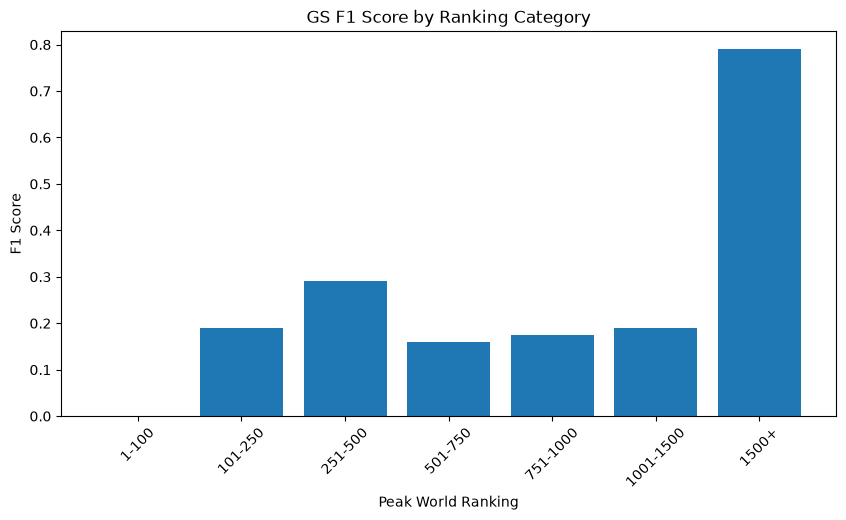

,precision,recall,f1-score,support
0.0,0.000000,0.000000,0.000000,4.000000
1.0,0.222222,0.250000,0.235294,8.000000
2.0,0.318182,0.291667,0.304348,24.000000
3.0,0.075472,0.166667,0.103896,24.000000
4.0,0.106061,0.291667,0.155556,24.000000
5.0,0.253012,0.375000,0.302158,56.000000
6.0,0.932773,0.664671,0.776224,334.000000
accuracy,0.554852,0.554852,0.554852,0.554852
macro avg,0.272532,0.291382,0.268211,474.000000
weighted avg,0.716215,0.554852,0.615175,474.000000


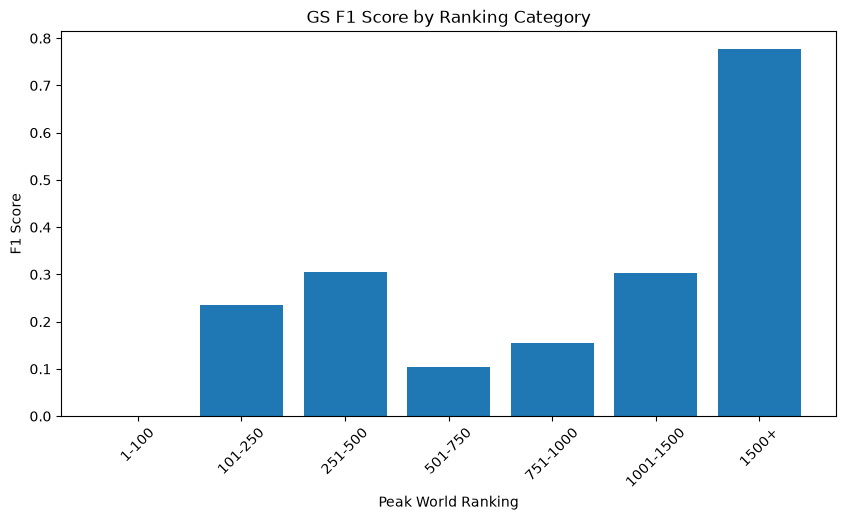

,precision,recall,f1-score,support
0.0,0.500000,0.500000,0.500000,2.000000
1.0,0.250000,0.300000,0.272727,10.000000
2.0,0.291667,0.304348,0.297872,23.000000
3.0,0.161290,0.161290,0.161290,31.000000
4.0,0.257576,0.472222,0.333333,36.000000
5.0,0.464286,0.191176,0.270833,68.000000
6.0,0.573529,0.639344,0.604651,61.000000
accuracy,0.367965,0.367965,0.367965,0.367965
macro avg,0.356907,0.366912,0.348673,231.000000
weighted avg,0.394103,0.367965,0.358782,231.000000


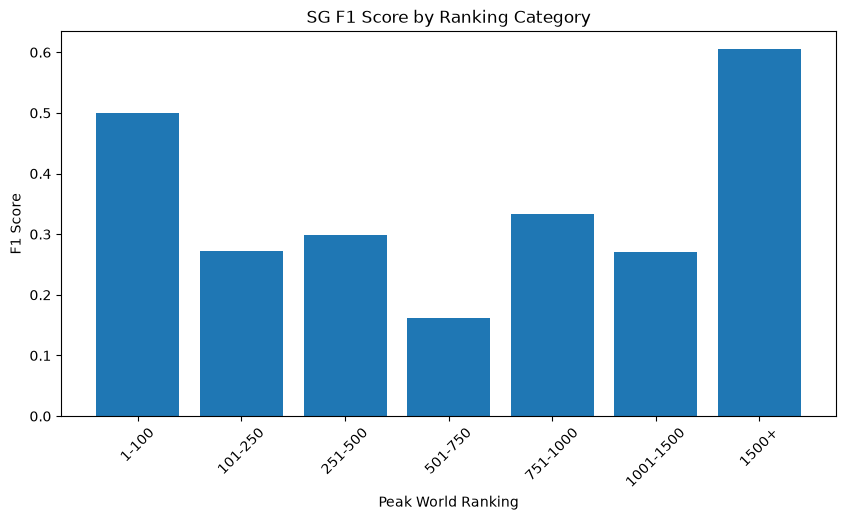

In [7]:
## reports
display(gs_report)

class_names = [
    "1-100",
    "101-250",
    "251-500",
    "501-750",
    "751-1000",
    "1001-1500",
    "1500+"
]

class_report = gs_report.iloc[:7]

plt.figure(figsize=(10, 5))

plt.bar(
    class_names,
    class_report["f1-score"]
)

plt.xlabel("Peak World Ranking")
plt.ylabel("F1 Score")
plt.title("GS F1 Score by Ranking Category")

plt.xticks(rotation=45)

plt.show()

## sl
display(sl_report)

class_names = [
    "1-100",
    "101-250",
    "251-500",
    "501-750",
    "751-1000",
    "1001-1500",
    "1500+"
]

class_report = sl_report.iloc[:7]

plt.figure(figsize=(10, 5))

plt.bar(
    class_names,
    class_report["f1-score"]
)

plt.xlabel("Peak World Ranking")
plt.ylabel("F1 Score")
plt.title("GS F1 Score by Ranking Category")

plt.xticks(rotation=45)

plt.show()

## sg report

display(sg_report)

class_names = [
    "1-100",
    "101-250",
    "251-500",
    "501-750",
    "751-1000",
    "1001-1500",
    "1500+"
]

class_report = sg_report.iloc[:7]

plt.figure(figsize=(10, 5))

plt.bar(
    class_names,
    class_report["f1-score"]
)

plt.xlabel("Peak World Ranking")
plt.ylabel("F1 Score")
plt.title("SG F1 Score by Ranking Category")

plt.xticks(rotation=45)

plt.show()

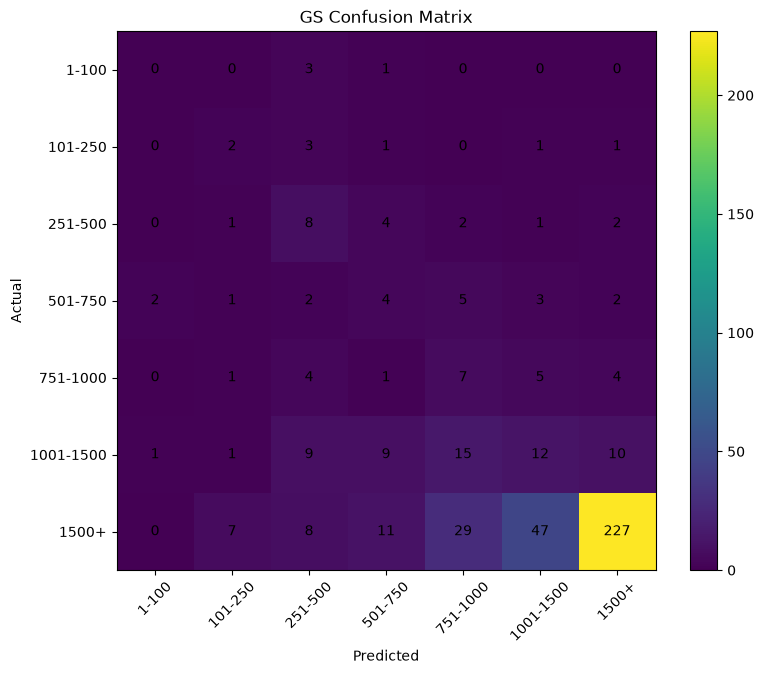

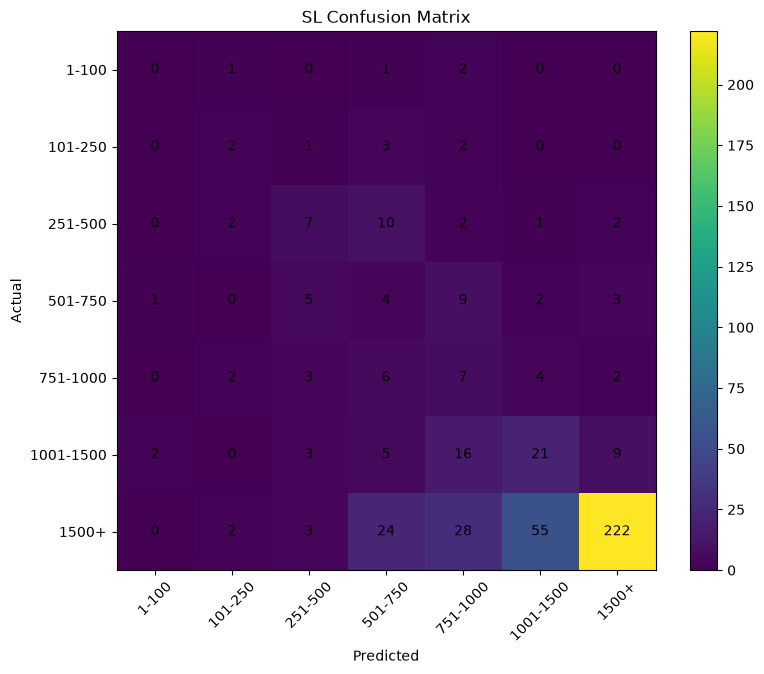

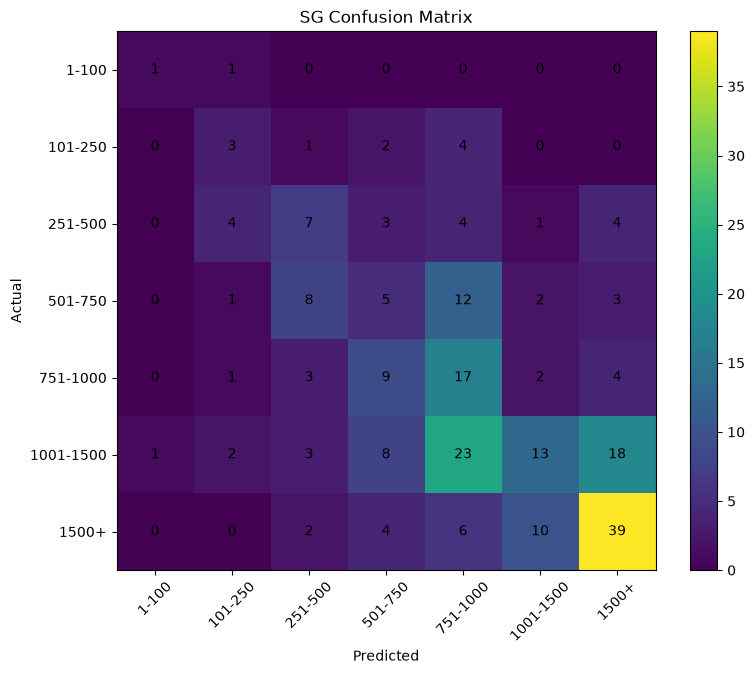

In [8]:
## confusion matrix
plt.figure(figsize=(9, 7))

plt.imshow(gs_cm)

plt.xticks(
    range(7),
    class_names,
    rotation=45
)

plt.yticks(
    range(7),
    class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("GS Confusion Matrix")

plt.colorbar()

# Add numbers inside squares
for i in range(7):
    for j in range(7):

        plt.text(
            j,
            i,
            gs_cm.iloc[i, j],
            ha="center",
            va="center"
        )

plt.show()


### SL
plt.figure(figsize=(9, 7))

plt.imshow(sl_cm)

plt.xticks(
    range(7),
    class_names,
    rotation=45
)

plt.yticks(
    range(7),
    class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SL Confusion Matrix")

plt.colorbar()

# Add numbers inside squares
for i in range(7):
    for j in range(7):

        plt.text(
            j,
            i,
            sl_cm.iloc[i, j],
            ha="center",
            va="center"
        )

plt.show()


## SG
plt.figure(figsize=(9, 7))

plt.imshow(sg_cm)

plt.xticks(
    range(7),
    class_names,
    rotation=45
)

plt.yticks(
    range(7),
    class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SG Confusion Matrix")

plt.colorbar()

# Add numbers inside squares
for i in range(7):
    for j in range(7):

        plt.text(
            j,
            i,
            sg_cm.iloc[i, j],
            ha="center",
            va="center"
        )

plt.show()

In [9]:
## individual athlete predictions
gs_results.head()
sl_results.head()
sg_results.head()

gs_wrong = gs_results[
    gs_results["Actual"] != gs_results["Predicted"]
]

display(gs_wrong)

## sl
sl_wrong = sl_results[
    sl_results["Actual"] != sl_results["Predicted"]
]

display(sl_wrong)


## sg
sg_wrong = sg_results[
    sg_results["Actual"] != sg_results["Predicted"]
]

display(sg_wrong)

,ACA,Name,FIS ID,Actual,Predicted,prob_WR_1_100,prob_WR_101_250,prob_WR_251_500,prob_WR_501_750,prob_WR_751_1000,prob_WR_1001_1500,prob_WR_1500_plus
1,87312,"Daigneault, Maxime",6100032,6.0,4,6.548707e-02,9.568166e-02,0.104917,0.235942,0.259496,0.133203,0.105273
6,77366,"Stone, Daphne",107859,6.0,5,5.757749e-06,1.714425e-04,0.032569,0.001354,0.231193,0.472832,0.261875
8,89246,"Heward, Charlotte",108356,6.0,5,1.797063e-08,1.284021e-05,0.010590,0.000674,0.242123,0.412301,0.334298
12,91068,"Tiviluk, Rachel",108936,3.0,4,2.539480e-07,5.491338e-04,0.007416,0.009212,0.518724,0.378541,0.085558
18,77716,"Rodgers, Tristan",104609,2.0,4,1.165175e-04,8.165048e-04,0.175520,0.098278,0.308888,0.207238,0.209143
...,...,...,...,...,...,...,...,...,...,...,...,...
444,68679,"Patterson, Soleil",107811,3.0,2,2.275717e-02,5.759521e-03,0.484314,0.336988,0.101485,0.036520,0.012177
446,68380,"Koczij, Agatka",108110,6.0,5,2.173079e-13,1.510507e-07,0.000053,0.000008,0.016289,0.549849,0.433801
450,72719,"Alexander, Kyle",104708,1.0,2,2.568439e-02,3.176015e-03,0.441221,0.123710,0.237112,0.098177,0.070920
451,74041,"Gendron, Ingrid",107905,6.0,4,1.134712e-04,5.714899e-03,0.091146,0.090966,0.398226,0.280894,0.132940


,ACA,Name,FIS ID,Actual,Predicted,prob_WR_1_100,prob_WR_101_250,prob_WR_251_500,prob_WR_501_750,prob_WR_751_1000,prob_WR_1001_1500,prob_WR_1500_plus
2,79702,"Noel, Louis-Philippe",104715,6.0,1,0.000850,0.747710,0.122496,0.074090,0.026029,0.020156,0.008668
4,81120,"Noakes, Sophia",108863,6.0,3,0.000010,0.000268,0.018078,0.350595,0.157059,0.301920,0.172071
12,92248,"Jensen, Hannah",108908,2.0,3,0.000066,0.036717,0.103819,0.488016,0.136529,0.186377,0.048476
13,109006,"Lambert, Lea",108822,2.0,3,0.000521,0.057966,0.129591,0.311585,0.206254,0.235213,0.058869
18,75665,"Sellery, Scott",6100087,6.0,5,0.000839,0.000853,0.015298,0.025591,0.193688,0.463369,0.300361
...,...,...,...,...,...,...,...,...,...,...,...,...
468,111333,"Savard, Lucas",6100954,3.0,2,0.002029,0.000314,0.571427,0.224890,0.134355,0.056512,0.010473
469,111303,"Berube, Lea",108984,5.0,4,0.000025,0.000004,0.018239,0.235266,0.448175,0.281481,0.016811
470,68650,"Nymann, Maja Renate",107790,6.0,3,0.000027,0.006610,0.053225,0.687709,0.115076,0.108374,0.028979
471,94048,"Dube, Sandrine",108481,6.0,5,0.000083,0.000044,0.027545,0.038445,0.335277,0.390579,0.208026


,ACA,Name,FIS ID,Actual,Predicted,prob_WR_1_100,prob_WR_101_250,prob_WR_251_500,prob_WR_501_750,prob_WR_751_1000,prob_WR_1001_1500,prob_WR_1500_plus
0,65281,"Lomas, Hannah",107654,5.0,4,7.366013e-08,0.000058,0.079314,0.049827,0.462711,0.334791,0.073298
2,89189,"Fortin, Daphne",108260,5.0,2,8.635388e-04,0.016677,0.285503,0.269995,0.200176,0.164305,0.062480
3,72727,"Jepsen, Mollie",107866,3.0,4,5.012411e-08,0.000021,0.016668,0.064812,0.425115,0.312173,0.181211
4,72125,"Salverda, Nicholas",6100398,5.0,4,1.322958e-04,0.001056,0.042032,0.130305,0.349405,0.226277,0.250793
5,70033,"Teague, Walter",104989,3.0,6,8.129521e-04,0.001139,0.001941,0.046255,0.032932,0.133335,0.783585
...,...,...,...,...,...,...,...,...,...,...,...,...
222,90707,"Green, Julia",108925,5.0,4,8.765613e-07,0.000044,0.005885,0.020586,0.510445,0.248988,0.214052
223,67217,"Topham, Jared",104471,4.0,3,8.490339e-04,0.004042,0.108005,0.430009,0.099024,0.167101,0.190970
224,80265,"Lennon, Bridget",45438,3.0,4,2.345835e-07,0.000138,0.058004,0.038548,0.438196,0.361179,0.103935
226,72692,"Shaw, Spencer",104567,6.0,5,1.404036e-04,0.000362,0.086731,0.061826,0.012762,0.497278,0.340900


In [10]:
## model's most confident predictions
gs_top100 = gs_results.sort_values(
    "prob_WR_1_100",
    ascending=False
)

gs_top100.head(20)

### sl
sl_top100 = sl_results.sort_values(
    "prob_WR_1_100",
    ascending=False
)

sl_top100.head(20)


### sg
sg_top100 = sg_results.sort_values(
    "prob_WR_1_100",
    ascending=False
)

sg_top100.head(20)

,ACA,Name,FIS ID,Actual,Predicted,prob_WR_1_100,prob_WR_101_250,prob_WR_251_500,prob_WR_501_750,prob_WR_751_1000,prob_WR_1001_1500,prob_WR_1500_plus
131,71719,"Alexander, Kyle",104708,0.0,0,0.649680,0.022446,0.014899,0.031425,0.031531,0.072119,0.177900
27,72898,"Courville, Frederic",104482,5.0,0,0.574234,0.320089,0.063622,0.020521,0.009166,0.006420,0.005947
218,67003,"Grabinski, Adrien",104694,2.0,2,0.173058,0.079692,0.527617,0.099321,0.036283,0.066811,0.017217
201,68888,"Smith, Mitch",104534,5.0,5,0.141315,0.036244,0.084088,0.080069,0.092701,0.287097,0.278485
136,67299,"Ross, Evan",104846,5.0,1,0.096641,0.301877,0.022448,0.225448,0.069095,0.065785,0.218706
145,93977,"Lafond, Mathis",6100391,3.0,3,0.071947,0.050121,0.053328,0.298037,0.186789,0.264601,0.075178
92,87220,"Poitras, Pierre-Elliot",6100034,1.0,4,0.069943,0.033028,0.046191,0.187473,0.329718,0.232959,0.100688
100,100533,"Mckinlay, Thomas",6100593,2.0,5,0.040575,0.026080,0.056032,0.191623,0.190266,0.311488,0.183935
150,75112,"Jaques, Michael",6100068,6.0,6,0.034375,0.007344,0.022513,0.062628,0.051750,0.380481,0.440908
84,79829,"Daigle, Thomas",104718,5.0,5,0.025158,0.011039,0.202855,0.144376,0.160084,0.355247,0.101242


In [11]:
## surprising predicitons
gs_results[
    (gs_results["Actual"] == 0) &
    (gs_results["Predicted"] >= 3)
]

## sl
sl_results[
    (sl_results["Actual"] == 0) &
    (sl_results["Predicted"] >= 3)
]


## sg
sg_results[
    (sg_results["Actual"] == 0) &
    (sg_results["Predicted"] >= 3)
]

,ACA,Name,FIS ID,Actual,Predicted,prob_WR_1_100,prob_WR_101_250,prob_WR_251_500,prob_WR_501_750,prob_WR_751_1000,prob_WR_1001_1500,prob_WR_1500_plus


In [12]:
## compare disciplines
accuracies = {}

for d in disciplines:

    accuracies[d.upper()] = data[d]["report"].loc[
        "accuracy",
        "precision"
    ]

print(accuracies)

{'GS': np.float64(0.5689277899343544), 'SL': np.float64(0.5548523206751055), 'SG': np.float64(0.36796536796536794)}
